--- ANTRENARE ȘI EVALUARE LOF (eBPF) ---
Date partajate: Train_Normal=25980, Test_Total=13559
Antrenare LOF...
Antrenare finalizată în 0.51 secunde!

RAPORT METRICI:
              precision    recall  f1-score   support

      Normal       1.00      0.91      0.95     11161
        Atac       0.71      1.00      0.83      2398

    accuracy                           0.93     13559
   macro avg       0.86      0.96      0.89     13559
weighted avg       0.95      0.93      0.93     13559

Scor AUC: 0.9962


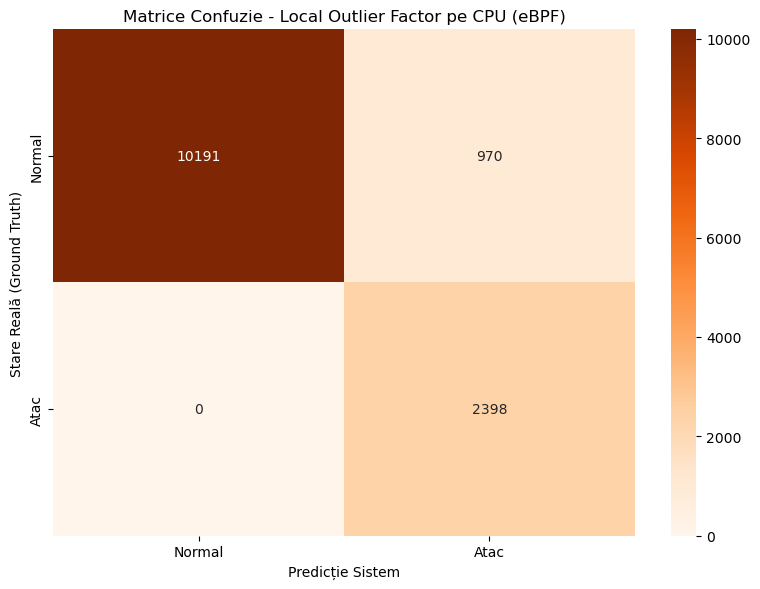

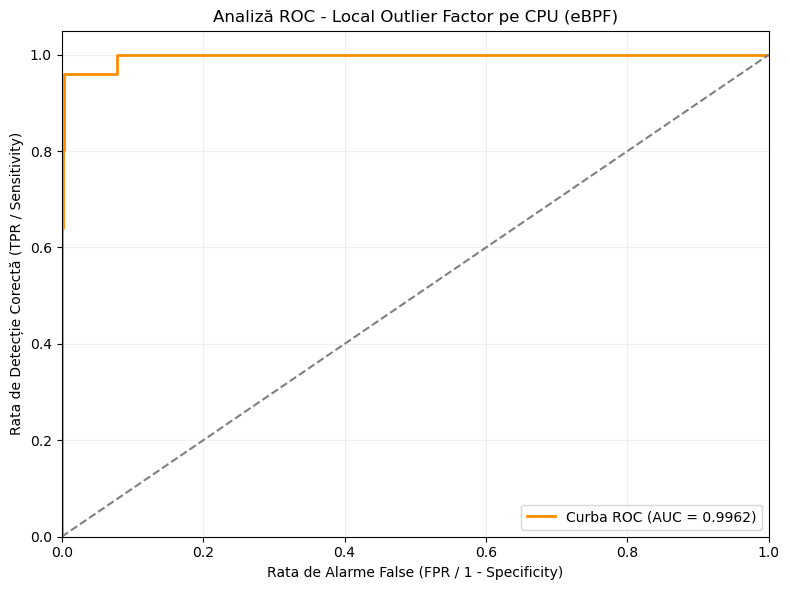


Toate rezultatele și graficele au fost salvate în: D:\disertatie\eBPF_WSL\rezultate_eBPF\LOF


In [1]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

dataset_path = 'dataset_eBPF.csv'
rezultate_path = r'D:\disertatie\eBPF_WSL\rezultate_eBPF\LOF'
os.makedirs(rezultate_path, exist_ok=True)

print("--- ANTRENARE ȘI EVALUARE LOF (eBPF) ---")
df = pd.read_csv(dataset_path)

X_raw = df[['pid', 'uid', 'gid', 'len', 'hour']].values
y = df['label'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

rng = np.random.default_rng(42)
X_clean = X_scaled + rng.normal(0, 1e-5, size=X_scaled.shape)

indices = np.arange(len(df))
np.random.seed(42)
np.random.shuffle(indices)

split_idx = int(len(df) * 0.7)
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = X_clean[train_indices][y[train_indices] == 0]
X_test = X_clean[test_indices]
y_test = y[test_indices]

print(f"Date partajate: Train_Normal={len(X_train)}, Test_Total={len(X_test)}")

computed_contamination = np.sum(y == 1) / len(y)
optimized_contamination = computed_contamination * 0.5 

lof = LocalOutlierFactor(n_neighbors=60, contamination=optimized_contamination, novelty=True, n_jobs=-1)

start_time = time.time()
print("Antrenare LOF...")
lof.fit(X_train)
train_time = time.time() - start_time
print(f"Antrenare finalizată în {train_time:.2f} secunde!")

decision_scores = lof.decision_function(X_test)
y_pred_raw = lof.predict(X_test)
y_pred = np.where(y_pred_raw == -1, 1, 0)

y_scores = -decision_scores
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test, y_pred, target_names=['Normal', 'Atac'])
print("\nRAPORT METRICI:")
print(report)
print(f"Scor AUC: {roc_auc:.4f}")

with open(os.path.join(rezultate_path, 'raport_ebpf_lof_cpu.txt'), 'w') as f:
    f.write(f"REZULTATE EBPF LOCAL OUTLIER FACTOR\nAUC: {roc_auc:.4f}\nTimp Antrenare: {train_time:.2f}s\n\n{report}")

# ==================== 1. GENERARE MATRICE DE CONFUZIE ====================
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Atac'], yticklabels=['Normal', 'Atac'])
plt.title('Matrice Confuzie - Local Outlier Factor pe CPU (eBPF)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_ebpf_lof_cpu.png'), dpi=300)
plt.show()

# ==================== 2. GENERARE CURBA ROC ====================
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curba ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.ylabel('Rata de Detecție Corectă (TPR / Sensitivity)')
plt.xlabel('Rata de Alarme False (FPR / 1 - Specificity)')
plt.title('Analiză ROC - Local Outlier Factor pe CPU (eBPF)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(rezultate_path, 'curba_roc_ebpf_lof_cpu.png'), dpi=300)
plt.show()

print(f"\nToate rezultatele și graficele au fost salvate în: {rezultate_path}")